# Day 04：门控的智慧 —— LSTM 的三个神奇阀门> ⏳ 第九周 · 记忆的诞生 · 第 4 天昨天我们看到 RNN 的"金鱼记忆"——梯度消失让它无法记住长距离信息。1997 年，Hochreiter 和 Schmidhuber 提出了一个天才的解决方案：**给记忆加门。**不是一扇门，而是三扇门：**遗忘门、输入门、输出门**。这三扇门精确控制信息的"进出留"，让记忆可以穿越时间而不衰减。这就是 LSTM（Long Short-Term Memory）——长短期记忆网络。**今天的任务**：1. 理解 LSTM 的核心创新：细胞状态 + 三个门2. 逐个拆解遗忘门、输入门、输出门3. 用代码手写 LSTM 单元---

## 1. 历史剧场：1997 年的"记忆突破"1997 年，Sepp Hochreiter 和 Jürgen Schmidhuber 发表了 LSTM 论文。他们的核心洞察是：> **RNN 的问题不是"没有记忆"，而是"记忆被 tanh 反复压缩，最终消失"。**> **解决方案：开辟一条不受压缩的"记忆高速公路"。**这条高速公路就是**细胞状态（Cell State）**，通常记为 $C_t$。与隐藏状态 $h_t$ 不同，细胞状态 $C_t$ 不经过 tananh 压缩——信息可以在其中几乎无损地传递，就像 ResNet 的跳跃连接一样！---

## 2. 生活隐喻：LSTM 是一个"有门的书房"想象你有一个书房，里面有一块**白板**（细胞状态）和三扇门：1. **遗忘门**：决定白板上哪些旧笔记要擦掉2. **输入门**：决定哪些新信息要写到白板上3. **输出门**：决定从白板上读取哪些信息作为当前输出具体场景：

<p align="center">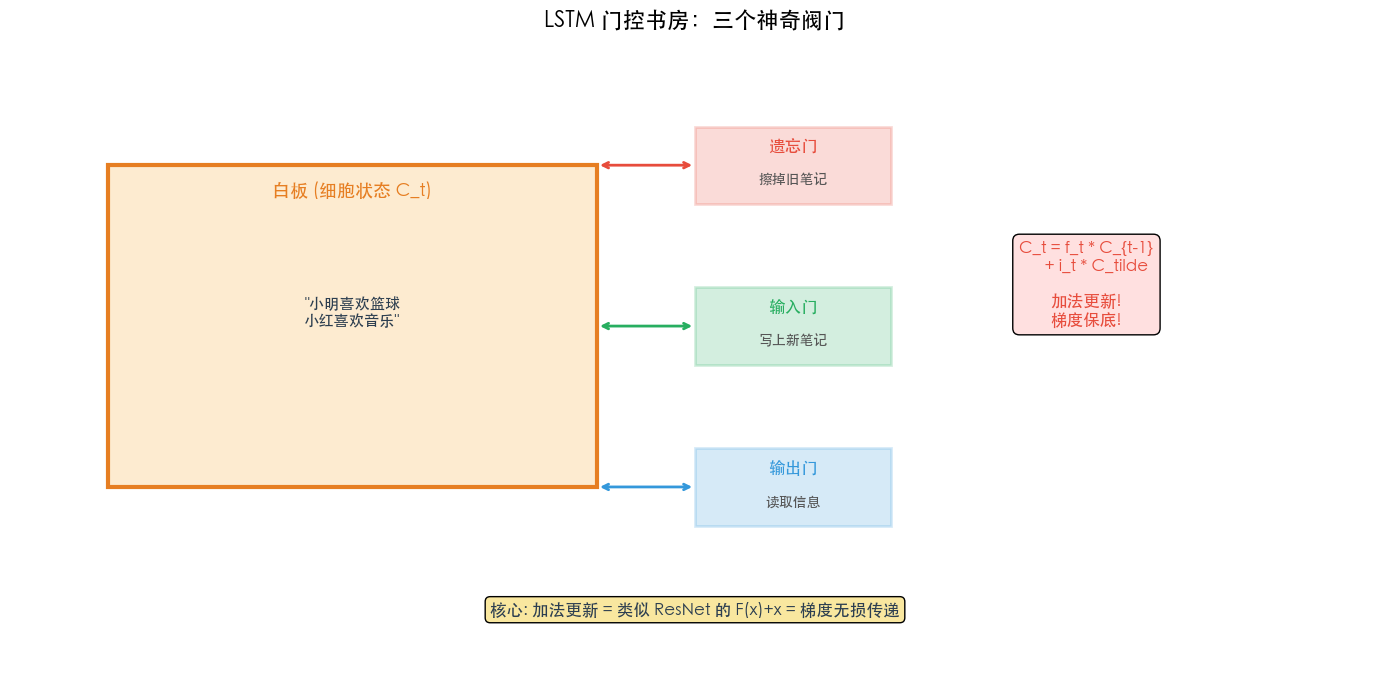</p>*LSTM 门控书房示意图*

你在读一段话："小明喜欢篮球，小红喜欢音乐"读到"小明"：  - 遗忘门：白板是空的，不用擦  - 输入门：写下"当前主语：小明"  - 输出门：输出"关注小明"读到"喜欢"：  - 遗忘门：保留"当前主语：小明"  - 输入门：添加"动作：喜欢"  - 输出门：输出"小明喜欢某事"读到"篮球"：  - 遗忘门：保留"小明"和"喜欢"  - 输入门：添加"对象：篮球"  - 输出门：输出"小明喜欢篮球"读到"小红"：  - 遗忘门：擦掉"小明"（主语换了！）  - 输入门：写下"当前主语：小红"  - 输出门：输出"关注小红"

**关键洞察**：遗忘门让 LSTM 能主动"忘记"不再需要的信息（比如主语换了），而细胞状态让需要保留的信息无损传递。---

## 3. 数学直觉：LSTM 的三个门### 3.1 遗忘门（Forget Gate）$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$- 输出范围：[0, 1]（sigmoid）- 含义：$f_t = 0$ 完全遗忘，$f_t = 1$ 完全保留- 直觉："白板上这条笔记还要不要？"### 3.2 输入门（Input Gate）$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$- $i_t$：范围 [0, 1]，控制"写多少"- $\tilde{C}_t$：范围 [-1, 1]，是"要写的新内容"- 直觉："新笔记写什么，写多少"### 3.3 更新细胞状态$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$- $f_t \odot C_{t-1}$：擦掉部分旧笔记- $i_t \odot \tilde{C}_t$：写上新笔记- **关键**：这里是加法！没有 tanh 压缩！梯度可以无损传递！### 3.4 输出门（Output Gate）$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$$$h_t = o_t \odot \tanh(C_t)$$- $o_t$：范围 [0, 1]，控制"读多少"- 直觉："从白板上读哪些信息"---

## 4. 代码实验室：手写 LSTM 单元

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写 LSTM 单元

In [ ]:
class SimpleLSTMCell:    def __init__(self, input_size, hidden_size):        self.input_size = input_size        self.hidden_size = hidden_size        concat_size = input_size + hidden_size        scale = np.sqrt(2.0 / concat_size)        self.W_f = np.random.randn(hidden_size, concat_size) * scale        self.b_f = np.ones(hidden_size)        self.W_i = np.random.randn(hidden_size, concat_size) * scale        self.b_i = np.zeros(hidden_size)        self.W_C = np.random.randn(hidden_size, concat_size) * scale        self.b_C = np.zeros(hidden_size)        self.W_o = np.random.randn(hidden_size, concat_size) * scale        self.b_o = np.zeros(hidden_size)    def sigmoid(self, x):        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))    def forward(self, x_t, h_prev, C_prev):        concat = np.concatenate([h_prev, x_t])        f_t = self.sigmoid(self.W_f @ concat + self.b_f)        i_t = self.sigmoid(self.W_i @ concat + self.b_i)        C_tilde = np.tanh(self.W_C @ concat + self.b_C)        o_t = self.sigmoid(self.W_o @ concat + self.b_o)        C_t = f_t * C_prev + i_t * C_tilde        h_t = o_t * np.tanh(C_t)        return h_t, C_t, f_t, i_t, o_t    def init_states(self):        return np.zeros(self.hidden_size), np.zeros(self.hidden_size)lstm = SimpleLSTMCell(input_size=4, hidden_size=8)print("LSTM 单元创建成功!")print(f"  遗忘门权重: {lstm.W_f.shape}")print(f"  输入门权重: {lstm.W_i.shape}")print(f"  输出门权重: {lstm.W_o.shape}")

### 4.2 逐步处理序列并观察门控

In [ ]:
np.random.seed(42)seq_len = 10h, C = lstm.init_states()print("LSTM 逐步处理序列：")print("-" * 70)print(f"{'时刻':>4} | {'遗忘门均值':>10} | {'输入门均值':>10} | {'输出门均值':>10} | {'C 范数':>8}")print("-" * 70)for t in range(seq_len):    x_t = np.random.randn(4)    h, C, f, i, o = lstm.forward(x_t, h, C)    print(f"  {t:2d} | {f.mean():>10.4f} | {i.mean():>10.4f} | {o.mean():>10.4f} | {np.linalg.norm(C):>8.4f}")

### 4.3 可视化门控活动

In [ ]:
np.random.seed(42)h, C = lstm.init_states()forget_gates, input_gates, output_gates = [], [], []cell_states = [C.copy()]for t in range(seq_len):    x_t = np.random.randn(4)    h, C, f, i, o = lstm.forward(x_t, h, C)    forget_gates.append(f)    input_gates.append(i)    output_gates.append(o)    cell_states.append(C.copy())fig, axes = plt.subplots(2, 2, figsize=(14, 10))for ax, gates, title, color in zip(    [axes[0,0], axes[0,1], axes[1,0]],    [forget_gates, input_gates, output_gates],    ['遗忘门活动 (0=遗忘, 1=保留)', '输入门活动 (0=忽略, 1=写入)', '输出门活动 (0=不读, 1=读取)'],    ['#e74c3c', '#27ae60', '#3498db']):    gate_array = np.array(gates)    im = ax.imshow(gate_array.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)    ax.set_xlabel('时间步', fontsize=11)    ax.set_ylabel('隐藏维度', fontsize=11)    ax.set_title(title, fontsize=13)    plt.colorbar(im, ax=ax)cell_array = np.array(cell_states[1:])im = axes[1,1].imshow(cell_array.T, aspect='auto', cmap='RdBu_r')axes[1,1].set_xlabel('时间步', fontsize=11)axes[1,1].set_ylabel('隐藏维度', fontsize=11)axes[1,1].set_title('细胞状态 (记忆高速公路)', fontsize=13)plt.colorbar(im, ax=axes[1,1])plt.suptitle('LSTM 门控活动可视化', fontsize=16, y=1.02)plt.tight_layout()plt.show()

### 解读- **遗忘门**：接近 1 表示保留旧记忆，接近 0 表示遗忘- **输入门**：接近 1 表示写入新信息，接近 0 表示忽略新输入- **输出门**：接近 1 表示输出该维度的信息，接近 0 表示隐藏- **细胞状态**：信息可以几乎无损地传递——这就是 LSTM 记忆的秘诀---

## 5. LSTM vs RNN：关键区别| | RNN | LSTM ||---|---|---|| 记忆载体 | $h_t$（隐藏状态） | $C_t$（细胞状态）+ $h_t$（隐藏状态） || 信息更新 | $h_t = \tanh(...)$（每次压缩） | $C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$（加法更新） || 梯度传播 | 乘法链（衰减） | 加法链（保底，类似 ResNet！） || 控制机制 | 无 | 三个门（遗忘/输入/输出） || 长距离记忆 | 差 | 好 |**核心洞察**：LSTM 的细胞状态更新是**加法**（$C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$），这和 ResNet 的 $out = F(x) + x$ 如出一辙！加法让梯度可以无损传递，这就是 LSTM 能记住长距离信息的数学根源。---

## 今日结语今天我们认识了 LSTM 的三个神奇阀门：1. **遗忘门**：决定忘记什么2. **输入门**：决定记住什么3. **输出门**：决定输出什么而最关键的创新是**细胞状态**——一条不受 tanh 压缩的"记忆高速公路"。它的加法更新（类似 ResNet 的跳跃连接）让信息可以穿越时间而不衰减。明天，我们将用 LSTM 实战，亲眼见证它如何碾压 RNN。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 有门的书房——控制进出 | LSTM——三个门控机制 || 白板——持久记忆 | 细胞状态 C_t——不加压的记忆通道 || 擦掉旧笔记 | 遗忘门——决定遗忘多少 || 写上新笔记 | 输入门——决定写入多少 || 从白板读信息 | 输出门——决定输出多少 || 记忆高速公路（类似 ResNet 近道） | 加法更新——梯度无损传递 |